# SNAP — Training Pipeline (FIXED)
Carica i CSV già pronti, costruisce la feature matrix e allena XGBoost con walk-forward validation.

**Modifiche rispetto alla versione originale** (fix per overfitting: AUC train/CV ~0.70 vs precision test ~0.47):
1. Spazio di ricerca iperparametri drasticamente ridotto + `gap` nel `TimeSeriesSplit` per evitare leakage tra fold adiacenti.
2. `best_score_` della RandomizedSearchCV trattato esplicitamente come **ottimistico** (selection bias su N candidati) — la metrica onesta resta solo il walk-forward.
3. Rimozione feature ridondanti/collineari (`macd`, `macd_signal` → si tiene solo `macd_hist`) prima del training.
4. Purge gap tra train/test nello split iniziale, per sicurezza contro feature con finestre rolling che attraversano il confine.
5. **Re-tuning periodico** degli iperparametri dentro il walk-forward (non più un unico `best_params` fisso per anni di dati attraverso regimi di mercato diversi).
6. Riportate anche `precision`/`recall`/`F1`, non solo accuracy/AUC.
7. Nota importante in fondo su un possibile leakage temporale in `src/sentiment_engine.py` da verificare manualmente (non visibile/verificabile da qui).

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

DATA_DIR   = './data'
MODELS_DIR = './models'
os.makedirs(MODELS_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linestyle': '--', 'grid.alpha': 0.6,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
})
print('✅ Librerie caricate.')

✅ Librerie caricate.


## 1. Caricamento CSV

In [39]:
# Mercato
df_market = pd.read_csv(
    os.path.join(DATA_DIR, 'btc-usd_market_data.csv'),
    index_col='timestamp', parse_dates=True
)
print(f'📈 Mercato:  {len(df_market)} settimane | {df_market.index[0].date()} → {df_market.index[-1].date()}')

# Mining
df_mining = pd.read_csv(
    os.path.join(DATA_DIR, 'bitcoin_mining_metrics.csv'),
    index_col='timestamp', parse_dates=True
)
print(f'⛏️  Mining:   {len(df_mining)} settimane')

# Energia
df_energy = pd.read_csv(
    os.path.join(DATA_DIR, 'bitcoin_energy_cost.csv'),
    index_col='timestamp', parse_dates=True
)
print(f'⚡ Energia:  {len(df_energy)} settimane | colonne: {list(df_energy.columns)}')

# Sentiment (già calcolato da Gemini)
df_sentiment = pd.read_csv(
    os.path.join(DATA_DIR, 'bitcoin_sentiment.csv'),
    index_col='timestamp', parse_dates=True
)
print(f'🐦 Sentiment: {len(df_sentiment)} settimane | dati reali: {df_sentiment["tweet_count"].gt(0).sum()}')

# Fear & Greed Index
import requests as _req
try:
    resp = _req.get("https://api.alternative.me/fng/?limit=1000&format=json", timeout=30)
    resp.raise_for_status()
    fng_data = resp.json()["data"]
    df_fng = pd.DataFrame(fng_data)
    df_fng["timestamp"] = pd.to_datetime(df_fng["timestamp"].astype(int), unit="s")
    df_fng = df_fng.set_index("timestamp")[["value"]].sort_index()
    df_fng["value"] = pd.to_numeric(df_fng["value"])
    df_fng_weekly = df_fng["value"].resample("W").agg(
        fear_greed_mean  = "mean",
        fear_greed_close = "last",
    )
    df_fng_weekly["fear_greed_delta"] = df_fng_weekly["fear_greed_close"].diff()
    fng_path = os.path.join(DATA_DIR, "bitcoin_fear_greed.csv")
    df_fng_weekly.to_csv(fng_path)
    print(f'😱 Fear & Greed: {len(df_fng_weekly)} settimane salvate in {fng_path}')
except Exception as e:
    print(f"[warn] Fear & Greed non disponibile: {e}")
    # Carica da CSV se già scaricato
    fng_path = os.path.join(DATA_DIR, "bitcoin_fear_greed.csv")
    if os.path.exists(fng_path):
        df_fng_weekly = pd.read_csv(fng_path, index_col="timestamp", parse_dates=True)
        print(f"😱 Fear & Greed caricato da CSV: {len(df_fng_weekly)} settimane")
    else:
        df_fng_weekly = None
        print("[warn] Fear & Greed non disponibile — verrà escluso dalla feature matrix")

df_sentiment.head()

📈 Mercato:  122 settimane | 2024-01-07 → 2026-05-03
⛏️  Mining:   122 settimane
⚡ Energia:  121 settimane | colonne: ['hash_rate_ths', 'power_gw', 'daily_consumption_gwh', 'annualised_twh', 'cost_per_btc_usd']
🐦 Sentiment: 122 settimane | dati reali: 122
😱 Fear & Greed: 144 settimane salvate in ./data/bitcoin_fear_greed.csv


,sentiment_score_mean,sentiment_score_weighted,positive_pct,negative_pct,tweet_count
timestamp,,,,,
2024-01-07,-0.031126,-0.066457,37.748344,41.059603,151.0
2024-01-14,-0.073000,-0.050540,28.000000,50.000000,100.0
2024-01-21,0.048352,0.133866,31.868132,27.472527,91.0
2024-01-28,0.068000,0.048793,50.000000,33.000000,100.0
2024-02-04,0.024490,0.061057,41.836735,27.551020,98.0


## 2. Feature Engineering

In [40]:
from src.sentiment_engine import SentimentEngine
from dotenv import load_dotenv
load_dotenv()

engine = SentimentEngine(api_key=os.getenv('GEMINI_API_KEY'))
print('✅ SentimentEngine pronto.')

✅ SentimentEngine pronto.


In [41]:
# Feature tecniche
tech = engine.compute_technical_features(df_market)
print(f'🔧 Tech features: {tech.shape[1]} colonne, {tech.shape[0]} settimane')

🔧 Tech features: 8 colonne, 122 settimane


In [42]:
# Feature energia
energy_feats = engine.compute_energy_features(df_energy)
print(f'⚡ Energy features: {energy_feats.shape[1]} colonne, {energy_feats.shape[0]} settimane')

⚡ Energy features: 3 colonne, 121 settimane


### ⚠️ Da verificare manualmente (fuori dallo scope di questo notebook)
`compute_technical_features` e `compute_energy_features` (in `src/sentiment_engine.py`) devono normalizzare/scalare ogni valore usando **solo dati fino a quella settimana** (rolling/expanding), mai statistiche calcolate su tutta la serie (es. `(x - x.full_series.mean()) / x.full_series.std()` o un `MinMaxScaler` fittato su tutto il dataset). Se una qualunque colonna (`volume_norm`, `hash_rate_norm`, `cost_per_btc_delta`, ecc.) usa min/max o mean/std globali, il modello vede indirettamente informazioni sul futuro durante il training: è la causa più comune di un gap enorme tra AUC in training/CV e precision in walk-forward reale, esattamente il sintomo che hai osservato. Controlla il codice sorgente di quelle due funzioni prima di fidarti di qualunque numero qui sotto.

In [43]:
# Gap filling sentiment (forward fill only — no look-ahead)
full_idx = pd.date_range(
    start=df_sentiment.index.min(),
    end=df_sentiment.index.max(),
    freq='W',
)
df_sentiment = df_sentiment.reindex(full_idx)
df_sentiment['has_data']    = (df_sentiment['tweet_count'] > 0).astype(int)
df_sentiment['tweet_count'] = df_sentiment['tweet_count'].fillna(0)

cols_interp = ['sentiment_score_mean', 'sentiment_score_weighted', 'positive_pct', 'negative_pct']
df_sentiment[cols_interp] = df_sentiment[cols_interp].ffill(limit=4).fillna(0)

print(f'Settimane con dati reali:  {df_sentiment["has_data"].sum()}')
print(f'Settimane interpolate:     {(df_sentiment["has_data"] == 0).sum()}')

Settimane con dati reali:  122
Settimane interpolate:     0


### 2c. Feature suggerita dal professore — Sentiment Momentum
Differenza tra il sentiment della settimana corrente e la media mobile delle `SENTIMENT_MOMENTUM_WINDOW` settimane precedenti (esclusa quella corrente). Calcolata **dopo** il gap-filling causale del sentiment, cosi la baseline non include mai la settimana che si sta valutando ne' settimane future.

In [44]:
SENTIMENT_MOMENTUM_WINDOW = 4  # coerente con le altre finestre a 4 settimane gia' nel codice

df_sentiment['sentiment_momentum'] = engine.compute_sentiment_momentum(
    df_sentiment, window=SENTIMENT_MOMENTUM_WINDOW, col='sentiment_score_mean'
)

print(f'Sentiment momentum ({SENTIMENT_MOMENTUM_WINDOW}w) calcolato.')
print(f'NaN nelle prime settimane (warm-up): {df_sentiment["sentiment_momentum"].isna().sum()}')
df_sentiment[['sentiment_score_mean', 'sentiment_momentum']].head(10)

Sentiment momentum (4w) calcolato.
NaN nelle prime settimane (warm-up): 4


,sentiment_score_mean,sentiment_momentum
2024-01-07,-0.031126,NaN
2024-01-14,-0.073000,NaN
2024-01-21,0.048352,NaN
2024-01-28,0.068000,NaN
2024-02-04,0.024490,0.021433
2024-02-11,0.036000,0.019040
2024-02-18,0.088679,0.044469
2024-02-25,0.085612,0.031319
2024-03-03,0.176087,0.117392
2024-03-10,0.007143,-0.089452


In [45]:
# Feature matrix
feature_matrix = tech.join(df_sentiment, how='left').join(energy_feats, how='left')

# Aggiungi Fear & Greed se disponibile
if df_fng_weekly is not None:
    feature_matrix = feature_matrix.join(df_fng_weekly, how='left')
    feature_matrix[['fear_greed_mean', 'fear_greed_close', 'fear_greed_delta']] = (
        feature_matrix[['fear_greed_mean', 'fear_greed_close', 'fear_greed_delta']]
        .ffill(limit=1)
    )
    print("😱 Fear & Greed aggiunto alla feature matrix")

feature_matrix = feature_matrix.ffill(limit=1)
feature_matrix = feature_matrix.iloc[:-1]  # ultima settimana non ancora chiusa

print(f'📊 Feature matrix: {feature_matrix.shape[0]} settimane × {feature_matrix.shape[1]} feature')
print(f'   Periodo: {feature_matrix.index[0].date()} → {feature_matrix.index[-1].date()}')
print()
for col in feature_matrix.columns:
    na = feature_matrix[col].isna().sum()
    print(f'  {col:<35} NaN: {na}')

😱 Fear & Greed aggiunto alla feature matrix
📊 Feature matrix: 121 settimane × 21 feature
   Periodo: 2024-01-07 → 2026-04-26

  log_return                          NaN: 1
  volatility_w                        NaN: 4
  rsi_14                              NaN: 14
  macd                                NaN: 0
  macd_signal                         NaN: 0
  macd_hist                           NaN: 0
  sharpe_4w                           NaN: 4
  volume_norm                         NaN: 3
  sentiment_score_mean                NaN: 0
  sentiment_score_weighted            NaN: 0
  positive_pct                        NaN: 0
  negative_pct                        NaN: 0
  tweet_count                         NaN: 0
  has_data                            NaN: 0
  sentiment_momentum                  NaN: 4
  cost_per_btc                        NaN: 0
  cost_per_btc_delta                  NaN: 1
  hash_rate_norm                      NaN: 3
  fear_greed_mean                     NaN: 0
  fear_greed_close

## 2b. FIX — Rimozione feature ridondanti/collineari
`macd`, `macd_signal` e `macd_hist` sono tre derivate della stessa serie e fortemente correlate tra loro (`macd_hist = macd - macd_signal`). Con poche centinaia di righe e 19 feature, questa ridondanza aumenta inutilmente la varianza del modello. Teniamo solo `macd_hist` (contiene già l'informazione di crossover) e scartiamo automaticamente qualunque altra coppia con correlazione assoluta > 0.95.

In [46]:
CORR_THRESHOLD = 0.95

# Rimozione esplicita: macd e macd_signal sono ridondanti rispetto a macd_hist
cols_to_drop = [c for c in ['macd', 'macd_signal'] if c in feature_matrix.columns]

# Rimozione feature a varianza zero (costanti su tutto il periodo, es. has_data
# se la copertura dei dati e' completa ogni settimana): non portano alcuna informazione
# discriminante, XGBoost le ignorerebbe comunque (importance 0), le togliamo esplicitamente.
zero_var_cols = [
    c for c in feature_matrix.select_dtypes(include=[np.number]).columns
    if feature_matrix[c].nunique(dropna=True) <= 1
]
if zero_var_cols:
    print(f'🗑️  Feature a varianza zero rimosse: {zero_var_cols}')
cols_to_drop += zero_var_cols

# Rimozione automatica di coppie altamente correlate (mantiene la prima colonna dell'ordine originale)
num_cols = feature_matrix.drop(columns=cols_to_drop).select_dtypes(include=[np.number]).columns
corr_matrix = feature_matrix[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
auto_drop = [c for c in upper.columns if any(upper[c] > CORR_THRESHOLD)]

all_drop = sorted(set(cols_to_drop + auto_drop))
print(f'🗑️  Feature rimosse per ridondanza/collinearità: {all_drop}')

feature_matrix = feature_matrix.drop(columns=all_drop)
print(f'📊 Feature matrix dopo pruning: {feature_matrix.shape[1]} colonne')

🗑️  Feature a varianza zero rimosse: ['has_data']
🗑️  Feature rimosse per ridondanza/collinearità: ['fear_greed_close', 'has_data', 'macd', 'macd_signal']
📊 Feature matrix dopo pruning: 17 colonne


## 3. Target

In [47]:
close = df_market['Close']

# FIX: offset posizionale (t_idx + 1) sostituito con verifica esplicita sulla DATA.
# Se anche una sola settimana mancasse nell'indice di df_market, 't_idx + 1' punterebbe
# silenziosamente a piu' di 7 giorni nel futuro senza generare errori: il target smetterebbe
# di rappresentare 'direzione della prossima settimana' in modo silenzioso. Qui invece si
# richiede esplicitamente che la settimana successiva nell'indice disti esattamente 7 giorni;
# altrimenti la riga viene scartata (NaN) invece di produrre un target semanticamente sbagliato.
EXPECTED_GAP = pd.Timedelta(weeks=1)

target = []
misaligned = 0
for t in feature_matrix.index:
    t_idx = close.index.get_loc(t)
    if t_idx + 1 >= len(close):
        target.append(np.nan)
        continue
    next_ts = close.index[t_idx + 1]
    if (next_ts - t) != EXPECTED_GAP:
        target.append(np.nan)   # gap nei dati: scarta invece di calcolare un target sbagliato
        misaligned += 1
        continue
    up = int(close.iloc[t_idx + 1] > close.iloc[t_idx])
    target.append(up)

y = pd.Series(target, index=feature_matrix.index, name='target_up')

print(f'⚠️  Settimane scartate per gap temporale (non esattamente 7 giorni dopo): {misaligned}')
print('Target distribution:')
print(y.value_counts())
print(f'\nUP ratio: {y.mean():.1%}')

⚠️  Settimane scartate per gap temporale (non esattamente 7 giorni dopo): 0
Target distribution:
target_up
1    61
0    60
Name: count, dtype: int64

UP ratio: 50.4%


## 4. Preparazione X/y

In [48]:
X = feature_matrix.dropna()
y_clean = y.loc[X.index].dropna()
X_clean = X.loc[y_clean.index]

# FIX: piccolo purge gap tra train e test iniziali, per sicurezza contro feature
# con finestre rolling che potrebbero attraversare il confine train/test.
PURGE_GAP = 2

split      = int(len(X_clean) * 0.7)
X_train    = X_clean.iloc[:split]
y_train    = y_clean.iloc[:split]
X_test     = X_clean.iloc[split + PURGE_GAP:]
y_test     = y_clean.iloc[split + PURGE_GAP:]

print(f'Dataset: {len(X_clean)} settimane totali')
print(f'Train:   {len(X_train)} settimane | Purge gap: {PURGE_GAP} | Test: {len(X_test)} settimane')

Dataset: 107 settimane totali
Train:   74 settimane | Purge gap: 2 | Test: 31 settimane


## 5. Hyperparameter Tuning (FIX)
Rispetto alla versione originale:
- Spazio di ricerca **molto** più piccolo e conservativo (alberi meno profondi, più regolarizzazione), coerente con un dataset di poche centinaia di righe settimanali.
- `n_iter` ridotto (20 invece di 50): meno candidati = meno selection bias sul punteggio di CV.
- `TimeSeriesSplit(..., gap=2)`: lascia un margine tra fold di train e validation, per non far leakare informazione tra settimane adiacenti tramite feature con finestre rolling.
- Il punteggio `best_score_` viene stampato ma **etichettato esplicitamente come ottimistico** — l'unica metrica su cui ci si deve basare per giudicare il modello è quella del walk-forward (sezione 6).

In [49]:
# Spazio di ricerca ridotto e più regolarizzato rispetto all'originale
param_grid = {
    'n_estimators':     [50, 100, 150],
    'max_depth':        [2, 3],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [3, 5, 8],
    'gamma':            [0, 0.1],
    'reg_alpha':        [0, 0.1],
    'reg_lambda':       [2, 5, 10],
}

def tune_hyperparams(X_tr, y_tr, n_iter=20, n_splits=5, gap=2, seed=42):
    """Ricerca iperparametri conservativa. Ritorna (best_params, best_cv_auc)."""
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    search = RandomizedSearchCV(
        estimator=xgb.XGBClassifier(eval_metric='logloss', random_state=seed),
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=tscv,
        random_state=seed,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_tr, y_tr)
    return search.best_params_, search.best_score_

best_params, best_cv_auc = tune_hyperparams(X_train, y_train)
print(f'Migliori parametri: {best_params}')
print(f'Miglior AUC in CV:  {best_cv_auc:.3f}  ⚠️ (ottimistico: max su N candidati, selection bias — non è la metrica finale)')

Migliori parametri: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 50, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Miglior AUC in CV:  0.579  ⚠️ (ottimistico: max su N candidati, selection bias — non è la metrica finale)


## 6. Walk-Forward Validation (FIX — con re-tuning periodico gated sui dati disponibili)
L'originale allenava gli iperparametri **una sola volta** sul primo 70% dei dati e li riusava identici per anni di walk-forward. Qui si ri-esegue una ricerca (più leggera) ogni `RETUNE_EVERY` settimane, ma **solo se ci sono abbastanza dati** (`MIN_RETUNE_SIZE`) per farlo in modo non rumoroso — con un dataset di ~100 settimane, ri-tunare su finestre di 50-80 righe con CV a 3 fold è troppo instabile e rischia di peggiorare il modello invece di adattarlo. Se il dataset è piccolo, il gating di fatto disabilita il re-tuning e si comporta come un tuning singolo — che è la scelta più sicura finché non si hanno più dati storici.

In [50]:
MIN_TRAIN_SIZE  = 30
RETUNE_EVERY    = 26   # ri-tuning circa ogni 6 mesi di dati settimanali
MIN_RETUNE_SIZE = 100  # non ri-tunare su finestre più piccole di questa: con pochi dati il CV interno diventa inaffidabile

predictions   = []
probabilities = []
actuals       = []
test_dates    = []

current_params = best_params
since_retune = 0
n_retunes = 0

for i in range(MIN_TRAIN_SIZE, len(X_clean)):
    X_tr = X_clean.iloc[:i]
    y_tr = y_clean.iloc[:i]
    X_te = X_clean.iloc[i:i+1]
    y_te = y_clean.iloc[i:i+1]

    if since_retune >= RETUNE_EVERY and len(X_tr) >= MIN_RETUNE_SIZE:
        try:
            current_params, _ = tune_hyperparams(X_tr, y_tr, n_iter=10, n_splits=3, gap=2)
            n_retunes += 1
        except Exception:
            pass  # se il re-tuning fallisce, tiene i parametri precedenti
        since_retune = 0

    model = xgb.XGBClassifier(**current_params, eval_metric='logloss', random_state=42)
    model.fit(X_tr, y_tr)

    predictions.append(model.predict(X_te)[0])
    probabilities.append(model.predict_proba(X_te)[0, 1])
    actuals.append(y_te.values[0])
    test_dates.append(X_te.index[0])
    since_retune += 1

predictions   = np.array(predictions)
probabilities = np.array(probabilities)
actuals       = np.array(actuals)

acc  = accuracy_score(actuals, predictions)
auc  = roc_auc_score(actuals, probabilities)
prec = precision_score(actuals, predictions, zero_division=0)
rec  = recall_score(actuals, predictions, zero_division=0)
f1   = f1_score(actuals, predictions, zero_division=0)

print(f'📊 Walk-Forward Validation (expanding window):')
print(f'   Dataset totale     : {len(X_clean)} settimane')
print(f'   Predizioni totali  : {len(predictions)}')
print(f'   Re-tuning eseguiti : {n_retunes}  (soglia minima: {MIN_RETUNE_SIZE} righe di train)')
print(f'   Accuracy  : {acc:.3f}')
print(f'   ROC-AUC   : {auc:.3f}')
print(f'   Precision : {prec:.3f}')
print(f'   Recall    : {rec:.3f}')
print(f'   F1        : {f1:.3f}')

📊 Walk-Forward Validation (expanding window):
   Dataset totale     : 107 settimane
   Predizioni totali  : 77
   Re-tuning eseguiti : 1  (soglia minima: 100 righe di train)
   Accuracy  : 0.442
   ROC-AUC   : 0.433
   Precision : 0.459
   Recall    : 0.737
   F1        : 0.566


### 6b. Diagnostica — l'AUC/precision qui sopra sono statisticamente diversi dal random?
Con un numero di predizioni così piccolo, un singolo valore di AUC o precision può essere solo rumore campionario. Calcoliamo un intervallo di confidenza bootstrap (resampling appaiato di `actuals`/`probabilities`) e controlliamo anche se la distribuzione del target è cambiata tra la parte iniziale (train) e la finestra di walk-forward (possibile regime shift, es. da mercato toro a orso), che da sola spiegherebbe un'accuracy sotto 0.5 se il modello ha imparato un bias di classe dal periodo di training.

In [51]:
N_BOOT = 2000
rng = np.random.RandomState(0)
n = len(actuals)

boot_auc, boot_prec, boot_acc = [], [], []
for _ in range(N_BOOT):
    idx = rng.randint(0, n, n)
    a_b, p_b, pred_b = actuals[idx], probabilities[idx], predictions[idx]
    if len(np.unique(a_b)) < 2:
        continue  # AUC non definito se il campione bootstrap ha una sola classe
    boot_auc.append(roc_auc_score(a_b, p_b))
    boot_prec.append(precision_score(a_b, pred_b, zero_division=0))
    boot_acc.append(accuracy_score(a_b, pred_b))

auc_ci  = np.percentile(boot_auc,  [2.5, 97.5])
prec_ci = np.percentile(boot_prec, [2.5, 97.5])
acc_ci  = np.percentile(boot_acc,  [2.5, 97.5])

print(f'📐 Intervalli di confidenza bootstrap al 95% (N={n} predizioni, {N_BOOT} resample):')
print(f'   AUC       : {auc:.3f}   CI95 [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]  {"— include 0.5: NON distinguibile dal random" if auc_ci[0] <= 0.5 <= auc_ci[1] else "— esclude 0.5: significativo"}')
print(f'   Precision : {prec:.3f}  CI95 [{prec_ci[0]:.3f}, {prec_ci[1]:.3f}]')
print(f'   Accuracy  : {acc:.3f}   CI95 [{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]  {"— include 0.5: NON distinguibile dal random" if acc_ci[0] <= 0.5 <= acc_ci[1] else "— esclude 0.5: significativo"}')

# Regime shift: UP ratio nel periodo di training iniziale vs nella finestra di walk-forward
up_ratio_train_period = y_clean.iloc[:MIN_TRAIN_SIZE].mean()
up_ratio_walkforward   = actuals.mean()
print()
print(f'📆 UP ratio periodo iniziale (primi {MIN_TRAIN_SIZE} settimane, warm-up): {up_ratio_train_period:.1%}')
print(f'📆 UP ratio nella finestra di walk-forward ({n} settimane):            {up_ratio_walkforward:.1%}')
print(f'   Un naive "predici sempre la classe maggioritaria del warm-up" avrebbe accuracy: '
      f'{max(up_ratio_walkforward, 1-up_ratio_walkforward):.3f} se il regime non fosse cambiato,')
print(f'   ma qui la classe maggioritaria osservata nel walk-forward è cambiata rispetto al warm-up di quanto sopra —')
print(f'   una differenza marcata indica un cambio di regime che un modello allenato solo sui dati iniziali non può cogliere.')

print()
print('➡️ Lettura onesta: se gli intervalli di confidenza includono 0.5/0.5, il messaggio corretto per la tesi')
print('   NON è "il modello performa peggio del random" (conclusione troppo forte per N così piccolo), ma')
print('   "con i dati disponibili non si osserva un segnale predittivo statisticamente distinguibile dal caso".')
print('   Per un task di direzione settimanale BTC è un risultato plausibile e onesto da riportare — la priorità')
print('   ora è verificare il leakage in sentiment_engine.py (nota sezione 2) e, se possibile, procurarsi più')
print('   storico settimanale: con ~100 osservazioni qualunque stima di AUC ha un errore standard enorme.')

📐 Intervalli di confidenza bootstrap al 95% (N=77 predizioni, 2000 resample):
   AUC       : 0.433   CI95 [0.310, 0.563]  — include 0.5: NON distinguibile dal random
   Precision : 0.459  CI95 [0.328, 0.581]
   Accuracy  : 0.442   CI95 [0.325, 0.558]  — include 0.5: NON distinguibile dal random

📆 UP ratio periodo iniziale (primi 30 settimane, warm-up): 53.3%
📆 UP ratio nella finestra di walk-forward (77 settimane):            49.4%
   Un naive "predici sempre la classe maggioritaria del warm-up" avrebbe accuracy: 0.506 se il regime non fosse cambiato,
   ma qui la classe maggioritaria osservata nel walk-forward è cambiata rispetto al warm-up di quanto sopra —
   una differenza marcata indica un cambio di regime che un modello allenato solo sui dati iniziali non può cogliere.

➡️ Lettura onesta: se gli intervalli di confidenza includono 0.5/0.5, il messaggio corretto per la tesi
   NON è "il modello performa peggio del random" (conclusione troppo forte per N così piccolo), ma
   "con i

## 7. Baseline di confronto

In [52]:
# Buy & Hold
buy_hold_acc = accuracy_score(actuals, np.ones(len(actuals), dtype=int))

# MACD Crossover (ricostruito da macd_hist, dato che macd/macd_signal sono stati rimossi come ridondanti)
macd_hist_vals = X_clean['macd_hist'].values[MIN_TRAIN_SIZE:]
macd_preds = (macd_hist_vals > 0).astype(int)
macd_prob  = (macd_hist_vals - macd_hist_vals.min()) / (macd_hist_vals.max() - macd_hist_vals.min() + 1e-9)
macd_acc   = accuracy_score(actuals, macd_preds)
macd_auc   = roc_auc_score(actuals, macd_prob)
macd_prec  = precision_score(actuals, macd_preds, zero_division=0)

# Random (media 50 seed)
random_aucs, random_accs, random_precs = [], [], []
for seed in range(50):
    rng = np.random.RandomState(seed)
    rand_preds = rng.randint(0, 2, len(actuals))
    random_aucs.append(roc_auc_score(actuals, rng.uniform(0, 1, len(actuals))))
    random_accs.append(accuracy_score(actuals, rand_preds))
    random_precs.append(precision_score(actuals, rand_preds, zero_division=0))
random_aucs  = np.array(random_aucs)
random_accs  = np.array(random_accs)
random_precs = np.array(random_precs)

print(f'📊 Confronto Walk-Forward\n')
print(f'{"Strategia":<20} {"Accuracy":<12} {"Precision":<12} {"ROC-AUC"}')
print('-' * 56)
print(f'{"XGBoost":<20} {acc:<12.3f} {prec:<12.3f} {auc:.3f}')
print(f'{"Buy & Hold":<20} {buy_hold_acc:<12.3f} {"N/A":<12} {"N/A"}')
print(f'{"MACD Crossover":<20} {macd_acc:<12.3f} {macd_prec:<12.3f} {macd_auc:.3f}')
print(f'{"Random (media)":<20} {random_accs.mean():<12.3f} {random_precs.mean():<12.3f} {random_aucs.mean():.3f}')

📊 Confronto Walk-Forward

Strategia            Accuracy     Precision    ROC-AUC
--------------------------------------------------------
XGBoost              0.442        0.459        0.433
Buy & Hold           0.494        N/A          N/A
MACD Crossover       0.506        0.500        0.494
Random (media)       0.497        0.489        0.513


## 8. Salvataggio modello

In [53]:
# FIX: il modello finale usa i parametri dell'ULTIMO re-tuning nel walk-forward (regime più recente)
# invece dei best_params fissati una sola volta all'inizio su dati vecchi.
final_model = xgb.XGBClassifier(**current_params, eval_metric='logloss', random_state=42)
final_model.fit(X_clean, y_clean)

model_path = os.path.join(MODELS_DIR, 'xgboost_model.json')
final_model.save_model(model_path)

# Salva anche le feature names per il predictor
import json
with open(os.path.join(MODELS_DIR, 'feature_names.json'), 'w') as f:
    json.dump(X_clean.columns.tolist(), f)

print(f'✅ Modello salvato in {model_path}')
print(f'   Feature: {X_clean.shape[1]}')
print(f'   Trained on: {len(X_clean)} settimane')
print(f'   Parametri finali: {current_params}')

✅ Modello salvato in ./models/xgboost_model.json
   Feature: 17
   Trained on: 107 settimane
   Parametri finali: {'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 150, 'min_child_weight': 8, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}


## 8b. Feature importance & ablation
Dato che il modello combinato non batte il random (sezione 6b), può essere utile per la discussione della tesi capire se **qualche gruppo di feature isolato** porta un minimo di segnale, anche se combinato con gli altri si perde nel rumore. Qui:
1. Guardiamo la feature importance del modello finale (solo indicativa — non prova causalità né generalizzazione).
2. Rifacciamo un walk-forward semplificato (senza re-tuning, iperparametri fissi conservativi) usando **solo** sottoinsiemi di feature per gruppo (tecniche, sentiment, on-chain/energia, fear&greed), per confrontare i rispettivi AUC.

🔍 Feature importance (gain-based, modello finale):
cost_per_btc_delta          0.079464
volatility_w                0.078512
tweet_count                 0.070652
fear_greed_delta            0.068744
sharpe_4w                   0.067217
volume_norm                 0.066858
positive_pct                0.061276
sentiment_score_weighted    0.060501
macd_hist                   0.060048
fear_greed_mean             0.059444
negative_pct                0.059009
sentiment_score_mean        0.055808
hash_rate_norm              0.053050
log_return                  0.050773
rsi_14                      0.044848
cost_per_btc                0.039088
sentiment_momentum          0.024710
dtype: float32


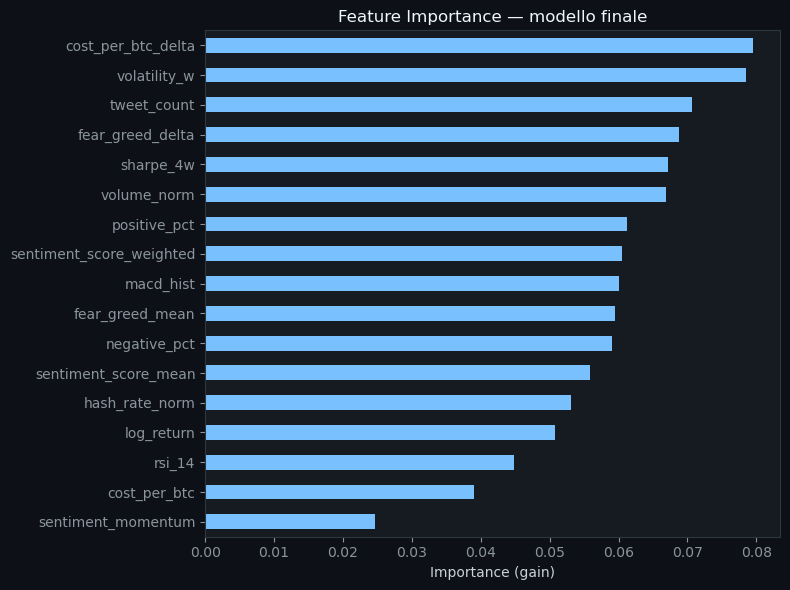

In [54]:
import matplotlib.pyplot as plt

importances = pd.Series(final_model.feature_importances_, index=X_clean.columns).sort_values(ascending=False)
print('🔍 Feature importance (gain-based, modello finale):')
print(importances)

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='#79c0ff')
ax.set_title('Feature Importance — modello finale', color='#f0f6fc')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

In [55]:
# Raggruppamento feature per famiglia (adatta i nomi se le tue colonne differiscono)
FEATURE_GROUPS = {
    'tecniche':      ['log_return', 'volatility_w', 'rsi_14', 'macd_hist', 'sharpe_4w', 'volume_norm'],
    'sentiment':     ['sentiment_score_mean', 'sentiment_score_weighted', 'positive_pct', 'negative_pct', 'tweet_count', 'has_data', 'sentiment_momentum'],
    'onchain_energy':['cost_per_btc', 'cost_per_btc_delta', 'hash_rate_norm'],
    'fear_greed':    ['fear_greed_mean', 'fear_greed_close', 'fear_greed_delta'],
}
# tiene solo le colonne effettivamente presenti dopo il pruning di correlazione
FEATURE_GROUPS = {g: [c for c in cols if c in X_clean.columns] for g, cols in FEATURE_GROUPS.items()}
for g, cols in FEATURE_GROUPS.items():
    print(f'{g}: {cols}')

tecniche: ['log_return', 'volatility_w', 'rsi_14', 'macd_hist', 'sharpe_4w', 'volume_norm']
sentiment: ['sentiment_score_mean', 'sentiment_score_weighted', 'positive_pct', 'negative_pct', 'tweet_count', 'sentiment_momentum']
onchain_energy: ['cost_per_btc', 'cost_per_btc_delta', 'hash_rate_norm']
fear_greed: ['fear_greed_mean', 'fear_greed_delta']


In [56]:
# Walk-forward semplificato (iperparametri fissi, NO re-tuning) per ogni sottoinsieme di feature.
# Serve solo a confrontare gruppi tra loro, non a produrre un numero definitivo — stessa avvertenza
# della sezione 6b: con N=77 servono comunque i CI bootstrap per interpretare qualunque differenza.

FIXED_PARAMS = dict(n_estimators=50, max_depth=2, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                    reg_lambda=5, reg_alpha=0.1, gamma=0.1)

def walk_forward_auc(cols, min_train=MIN_TRAIN_SIZE):
    X_sub = X_clean[cols]
    preds, probs, acts = [], [], []
    for i in range(min_train, len(X_sub)):
        X_tr, y_tr = X_sub.iloc[:i], y_clean.iloc[:i]
        X_te = X_sub.iloc[i:i+1]
        m = xgb.XGBClassifier(**FIXED_PARAMS, eval_metric='logloss', random_state=42)
        m.fit(X_tr, y_tr)
        probs.append(m.predict_proba(X_te)[0, 1])
        preds.append(m.predict(X_te)[0])
        acts.append(y_clean.iloc[i])
    acts, probs, preds = np.array(acts), np.array(probs), np.array(preds)
    return roc_auc_score(acts, probs), accuracy_score(acts, preds), acts, probs

def bootstrap_auc_ci(acts, probs, n_boot=1000, seed=0):
    rng = np.random.RandomState(seed)
    n = len(acts)
    vals = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(acts[idx])) < 2:
            continue
        vals.append(roc_auc_score(acts[idx], probs[idx]))
    return np.percentile(vals, [2.5, 97.5])

results = {}
for group_name, cols in FEATURE_GROUPS.items():
    if len(cols) == 0:
        continue
    g_auc, g_acc, g_acts, g_probs = walk_forward_auc(cols)
    ci = bootstrap_auc_ci(g_acts, g_probs)
    results[group_name] = (g_auc, g_acc, ci)

# anche tutte le feature insieme, con gli stessi iperparametri fissi (per confronto equo con i gruppi)
all_auc, all_acc, all_acts, all_probs = walk_forward_auc(list(X_clean.columns))
all_ci = bootstrap_auc_ci(all_acts, all_probs)
results['tutte_le_feature'] = (all_auc, all_acc, all_ci)

print(f'{"Gruppo":<18} {"AUC":<8} {"Accuracy":<10} {"CI95 AUC"}')
print('-' * 55)
for g, (a, acc_, ci) in results.items():
    flag = ' (include 0.5)' if ci[0] <= 0.5 <= ci[1] else ' (esclude 0.5)'
    print(f'{g:<18} {a:<8.3f} {acc_:<10.3f} [{ci[0]:.3f}, {ci[1]:.3f}]{flag}')

Gruppo             AUC      Accuracy   CI95 AUC
-------------------------------------------------------
tecniche           0.391    0.455      [0.265, 0.521] (include 0.5)
sentiment          0.426    0.506      [0.301, 0.555] (include 0.5)
onchain_energy     0.420    0.481      [0.302, 0.553] (include 0.5)
fear_greed         0.482    0.494      [0.358, 0.612] (include 0.5)
tutte_le_feature   0.435    0.468      [0.303, 0.567] (include 0.5)


## 9. Backtesting

In [57]:
close = df_market['Close']

bt = pd.DataFrame({
    'prediction':  predictions,
    'probability': probabilities,
    'actual':      actuals,
}, index=test_dates)

bt['close_t']  = close.reindex(bt.index).values
bt['close_t1'] = [close.iloc[close.index.get_loc(t) + 1] for t in bt.index]
bt['return_w'] = bt['close_t1'] / bt['close_t'] - 1

CAPITAL_START   = 10_000.0
TRANSACTION_FEE = 0.001

capital_model = CAPITAL_START
capital_bh    = CAPITAL_START
equity_model  = []
equity_bh     = []
trades        = 0
in_position   = False

for _, row in bt.iterrows():
    ret = row['return_w']
    capital_bh *= (1 + ret)
    if row['prediction'] == 1:
        if not in_position:
            capital_model *= (1 - TRANSACTION_FEE)
            in_position = True
            trades += 1
        capital_model *= (1 + ret)
    else:
        if in_position:
            capital_model *= (1 - TRANSACTION_FEE)
            in_position = False
    equity_model.append(capital_model)
    equity_bh.append(capital_bh)

bt['equity_model'] = equity_model
bt['equity_bh']    = equity_bh

ret_model = bt['equity_model'].iloc[-1] / CAPITAL_START - 1
ret_bh    = bt['equity_bh'].iloc[-1]    / CAPITAL_START - 1

def sharpe(eq): 
    r = eq.pct_change().dropna()
    return r.mean() / r.std() * np.sqrt(52)

def max_drawdown(eq):
    return ((eq - eq.cummax()) / eq.cummax()).min()

print(f'📊 Backtesting — Risultati\n')
print(f'  Numero di trade: {trades}')
print(f'{"Metrica":<28} {"XGBoost":<15} {"Buy & Hold"}')
print('-' * 55)
print(f'{"Rendimento totale":<28} {ret_model*100:>+.1f}%          {ret_bh*100:>+.1f}%')
print(f'{"Capitale finale":<28} ${capital_model:>10,.0f}    ${capital_bh:>10,.0f}')
print(f'{"Sharpe Ratio (ann.)":<28} {sharpe(bt["equity_model"]):>10.3f}    {sharpe(bt["equity_bh"]):>10.3f}')
print(f'{"Max Drawdown":<28} {max_drawdown(bt["equity_model"])*100:>+.1f}%          {max_drawdown(bt["equity_bh"])*100:>+.1f}%')

📊 Backtesting — Risultati

  Numero di trade: 12
Metrica                      XGBoost         Buy & Hold
-------------------------------------------------------
Rendimento totale            -22.8%          -5.2%
Capitale finale              $     7,715    $     9,482
Sharpe Ratio (ann.)              -0.670        -0.100
Max Drawdown                 -48.4%          -46.8%


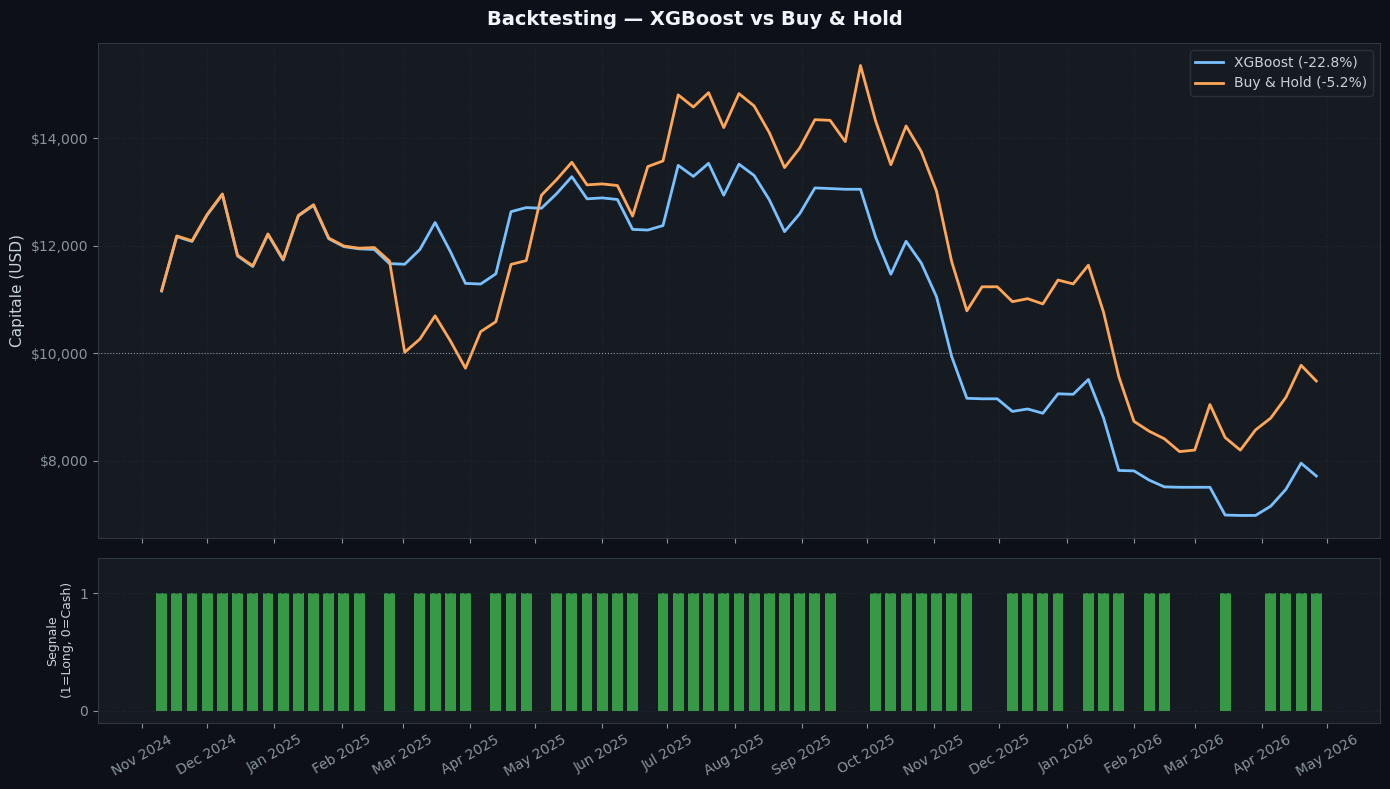

✅ Grafico backtesting salvato.


In [58]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Backtesting — XGBoost vs Buy & Hold', fontsize=14,
             fontweight='bold', color='#f0f6fc')

axes[0].plot(bt.index, bt['equity_model'], color='#79c0ff', linewidth=2,
             label=f'XGBoost ({ret_model*100:+.1f}%)')
axes[0].plot(bt.index, bt['equity_bh'],    color='#ffa657', linewidth=2,
             label=f'Buy & Hold ({ret_bh*100:+.1f}%)')
axes[0].axhline(CAPITAL_START, color='#8b949e', linewidth=0.8, linestyle=':')
axes[0].set_ylabel('Capitale (USD)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(fontsize=10)
axes[0].grid(True)

colors_signal = ['#3fb950' if p == 1 else '#f85149' for p in bt['prediction']]
axes[1].bar(bt.index, bt['prediction'], color=colors_signal, width=5, alpha=0.8)
axes[1].set_ylabel('Segnale\n(1=Long, 0=Cash)', fontsize=9)
axes[1].set_ylim(-0.1, 1.3)
axes[1].set_yticks([0, 1])
axes[1].grid(True, axis='y')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_backtesting.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafico backtesting salvato.')